In [1]:
import matplotlib.pyplot as plt

In [2]:
import json
import os

path = os.getcwd().split('/')[:-1]
response_filename = '/'.join(path) + '/dataset/response.json'

with open(response_filename, 'r') as f:
    response_data = json.load(f)

dr1_filename = '/'.join(path) + '/dataset/drop-response-1.json'
with open(dr1_filename, 'r') as f:
    drop1_data = json.load(f)

dr2_filename = '/'.join(path) + '/dataset/drop-response-2.json'
with open(dr2_filename, 'r') as f:
    drop2_data = json.load(f)

dr3_filename = '/'.join(path) + '/dataset/drop-response-3.json'
with open(dr3_filename, 'r') as f:
    drop3_data = json.load(f)

dr4_filename = '/'.join(path) + '/dataset/drop-response-4.json'
with open(dr4_filename, 'r') as f:
    drop4_data = json.load(f)


In [3]:
def plot_drop_data(data):
    i = data['data'][0]['actions'].index(None)
    plt.plot(data['data'][0]['sensor_data'][i-10:i+50])
    plt.plot(data['data'][0]['actions'][i-10:i+50])

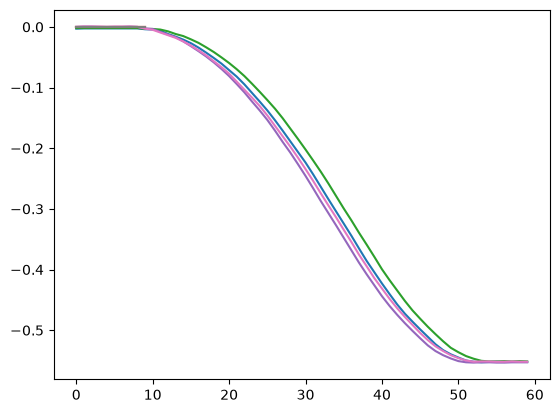

In [4]:
plot_drop_data(drop1_data)
plot_drop_data(drop2_data)
plot_drop_data(drop3_data)
plot_drop_data(drop4_data)


In [5]:
def process_data(data):
    i = data['actions'].index(None)
    new_sensor_data = data['sensor_data'][i-10:i+50]
    new_actions = data['actions'][i-10:i+50]
    
    return {
        'type': data['type'],
        'targets': data['targets'],
        'sensor_data': new_sensor_data,
        'actions': new_actions
    }

for item in [drop1_data, drop2_data, drop3_data, drop4_data]:
    for rollout in item['data']:
        new_data = process_data(rollout)
        response_data['data'].append(new_data)

In [6]:
type_set = set()
for item in response_data['data']:
    type_set.add(item['type'])

type_set


{'chirp', 'drop', 'prbs', 'ramp', 'square', 'step', 'triangle'}

In [7]:
target_set = set()
for item in response_data['data']:
    try:
        for item in item['targets']:
            target_set.add(item)
    except:
        print(item)

target_set

{'force_limit', 'frictionloss', 'kp', 'tau'}

In [ ]:
path = os.getcwd().split('/')[:-1]
filename = '/'.join(path) + '/dataset/dataset.json'

with open(filename, 'w') as f:
    json.dump(data, f)

